<div style = "border: 1px solid black">
<b><center><font size = "5"> Projecto Prático 1 </font><center></b>

<b><center><font size = "3"> Regressão linear e logística
</font><center></b>
</div>



---



`Nome:` Leonor Rebola <br>
`Número:` 53663 <br>
`Curso:` Inteligência Artificial e Ciência de Dados <br>
`Email:` leonor.rebola@ubi.pt <br>
`UC:` Aprendizagem Computacional <br>


---



`Objetivo:` Desenvolver e analisar um modelo de classificação para imagens MNIST.


---



# **Leitura do ficheiro**

---



In [ ]:
from google.colab import files
import zipfile
import os

# Ler o ficheiro
uploaded = files.upload()

# Para descompactar a pasta
zip_path = '/content/mnist.zip'
extract_path = '/content/'

os.makedirs(extract_path, exist_ok = True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

Saving mnist.zip to mnist (1).zip


# **Leitura e transformação das imagens**

---



In [ ]:
import numpy as np
from PIL import Image
import os

# Caminho da pasta descomprimida
base_path = '/content/mnist'

X = []
y = []

for filename in os.listdir(base_path):
    if filename.endswith('.png'):
        img_path = os.path.join(base_path, filename)
        img = Image.open(img_path).convert('L')  # grayscale
        img = img.resize((28, 28))               # Redimensionar para 28x28 píxeis
        img_array = np.array(img).flatten()      # Transformar a imagem em vetor unidimensional
        X.append(img_array)

        # Extração dos rótulos
        label = int(filename.split('_')[1])
        y.append(label)

X = np.array(X).astype(float)
y = np.array(y).astype(int)

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print("Exemplo de labels extraídas:", y[:10])
print("Labels únicos encontrados:", np.unique(y))

Formato de X: (107730, 784)
Formato de y: (107730,)
Exemplo de labels extraídas: [0 9 6 5 2 5 4 1 7 1]
Labels únicos encontrados: [0 1 2 3 4 5 6 7 8 9]


# **Regressão logística (Implementation I)**

---



Formato de X: (107730, 784)
Formato de y: (107730, 10)
Número de classes: 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1992 - loss: 2.1813 - val_accuracy: 0.5304 - val_loss: 1.5709
Epoch 2/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3990 - loss: 1.6152 - val_accuracy: 0.6318 - val_loss: 1.1635
Epoch 3/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4744 - loss: 1.3636 - val_accuracy: 0.7094 - val_loss: 0.9589
Epoch 4/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5200 - loss: 1.2320 - val_accuracy: 0.7538 - val_loss: 0.8315
Epoch 5/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5503 - loss: 1.1492 - val_accuracy: 0.7806 - val_loss: 0.7359
Epoch 6/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5754 - loss: 1.0937 - val_accuracy: 0.8026 - val_loss: 0.6691
Epoch 7/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5946 - loss: 1.0474 - val_accuracy: 0.8242 - val_loss: 0.6091
Epoch 8/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6156 - loss: 

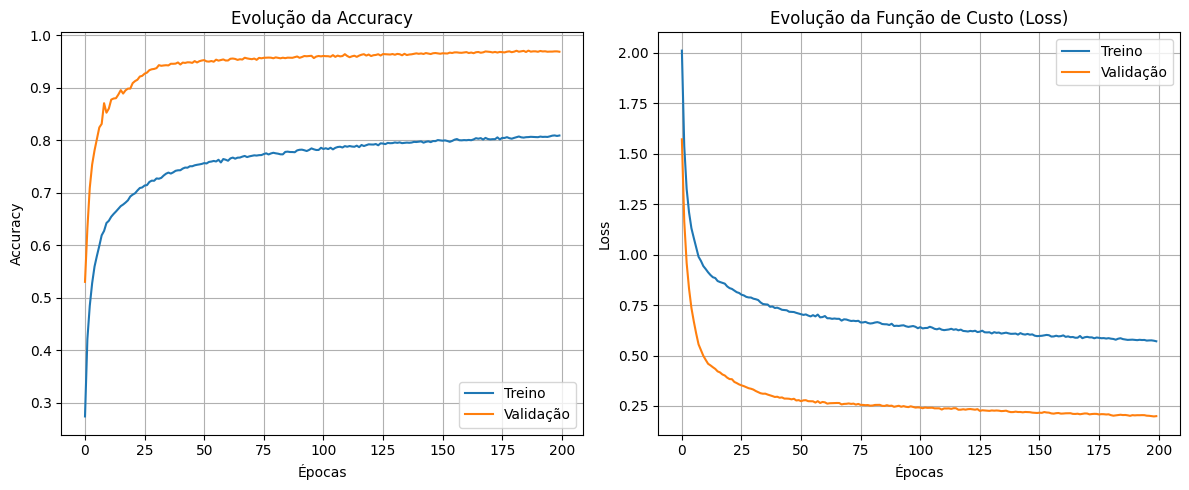

In [ ]:
import numpy as np
import keras as K
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Softmax, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import categorical_crossentropy
import matplotlib.pyplot as plt

# Normalização
X = X.astype('float32')
if X.max() > 1.0: # Caso já tenha sido feita a normalização
  X = X / 255.0

# One-hot encoding
# Proteção contra múltiplas codificações
if y.ndim > 1 and y.shape[1] == 10 and np.all((y == 0) | (y == 1)):
    y = np.argmax(y, axis=1)

tot_classes = len(np.unique(y))
y = to_categorical(y, num_classes=tot_classes)

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Número de classes: {tot_classes}")

# Divisão treino/teste
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Modelo
model = Sequential()
model.add(Dense(16, input_shape=(X.shape[1],)))
model.add(Activation('sigmoid'))
model.add(Dropout(0.2))
model.add(Dense(8))
model.add(Activation('sigmoid'))
model.add(Dropout(0.2))
model.add(Dense(tot_classes))
model.add(Softmax())

# Função de custo
def J(y_true, y_pred):
  return categorical_crossentropy(y_true, y_pred)

# Treino
model.compile(optimizer='adam', loss=J, metrics=['accuracy'])
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = 200, batch_size = 64, verbose = 1, callbacks = [early_stop])

# Avaliação
loss, acc = model.evaluate(X_val, y_val, verbose = 0)
print(f"Loss: {loss:.4f} - Accuracy: {acc:.4f}")

history = model.history.history

# Gráficos da evolução
plt.figure(figsize=(12, 5))
# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Treino')
plt.plot(history['val_accuracy'], label='Validação')
plt.title('Evolução da Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
# Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Treino')
plt.plot(history['val_loss'], label='Validação')
plt.title('Evolução da Função de Custo (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Na Implementation I, foi utilizada um modelo de duas camadas com 16 e 8 neurónios com activação sigmoid, com um lote de tamanho 64 e um total de 200 épocas, com regularização por Dropout de 30% em ambas as camadas ocultas.

\
Apesar de ser utilizado o critério EarlyStopping, neste caso o modelo continuou a melhorar até ao final das épocas, atingindo uma accuracy de 96.91% e uma loss de 0.1982 na validação.

\
Nos gráficos, também podemos observar uma evolução rápida, com a accuracy de validação a superar ligeiramente a de treino. Já a função de custo desceu de forma consistente, indicando que o modelo conseguiu extrair padrões relevantes.

# **Regressão logística através das características (Implementation II)**

---



Formato de X: (107730, 784)
Formato de y: (107730, 10)
Número de classes: 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1383 - loss: 2.2762 - val_accuracy: 0.3845 - val_loss: 1.8470
Epoch 2/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3276 - loss: 1.8481 - val_accuracy: 0.4745 - val_loss: 1.5537
Epoch 3/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3872 - loss: 1.6528 - val_accuracy: 0.4975 - val_loss: 1.4272
Epoch 4/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4171 - loss: 1.5576 - val_accuracy: 0.5390 - val_loss: 1.3254
Epoch 5/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4471 - loss: 1.4783 - val_accuracy: 0.5753 - val_loss: 1.2302
Epoch 6/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4724 - loss: 1.4125 - val_accuracy: 0.5913 - val_loss: 1.1449
Epoch 7/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4872 - loss: 1.3584 - val_accuracy: 0.6248 - val_loss: 1.0797
Epoch 8/200
1431/1431 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5092 - loss: 1

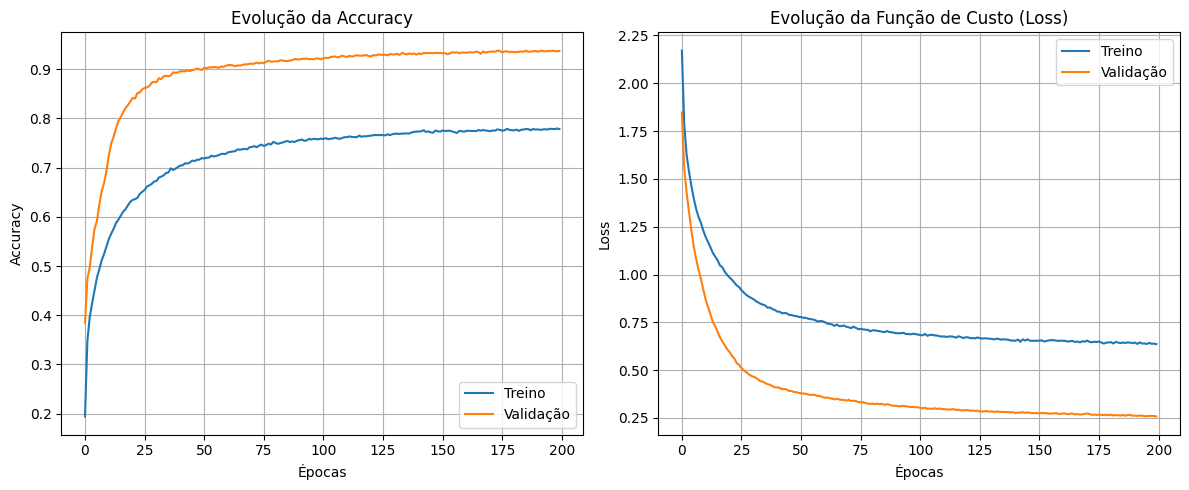

In [ ]:
import numpy as np
import keras as K
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Softmax, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import categorical_crossentropy
import matplotlib.pyplot as plt

# Funções de extração
def extract_features(img):
    img = img.reshape(28, 28)

    # Histograma com 16 bins
    hist, _ = np.histogram(img, bins=16, range=(0, 255))
    hist = hist / np.sum(hist)

    # Médias por zona (4x4 blocos)
    block_means = []
    for i in range(0, 28, 7):
        for j in range(0, 28, 7):
            block = img[i:i+7, j:j+7]
            block_means.append(np.mean(block))
    block_means = np.array(block_means)

    # Contagem de píxeis
    proj_horizontal = np.sum(img, axis=1)
    proj_vertical = np.sum(img, axis=0)

    return np.concatenate([hist, block_means, proj_horizontal, proj_vertical])

# Normalização
X = X.astype('float32')
if X.max() <= 1.0: # Caso já tenha sido feita a normalização
    X = X * 255.0

# One-hot encoding
# Proteção contra múltiplas codificações
if y.ndim > 1 and y.shape[1] == 10 and np.all((y == 0) | (y == 1)):
    y = np.argmax(y, axis=1)

tot_classes = len(np.unique(y))
y = to_categorical(y, num_classes = tot_classes)

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Número de classes: {tot_classes}")

# Extração de características
X_train_feat = np.array([extract_features(img) for img in X])
# Normalização das features
max_val = np.max(X_train_feat, axis=0, keepdims=True)
max_val[max_val == 0] = 1
X_feat = X_train_feat / max_val

# Divisão treino/validação
X_train, X_val, y_train, y_val = train_test_split(X_feat, y, test_size=0.15, random_state=42, stratify=np.argmax(y, axis=1))

# Modelo
model = Sequential()
model.add(Dense(16, input_shape=(88,)))  # 88 features (16+16+28+28)
model.add(Activation('sigmoid'))
model.add(Dropout(0.2))
model.add(Dense(8))
model.add(Activation('sigmoid'))
model.add(Dropout(0.2))
model.add(Dense(tot_classes))
model.add(Softmax())

# Função de custo
def J(y_true, y_pred):
  return categorical_crossentropy(y_true, y_pred)

# Treino
model.compile(optimizer='adam', loss=J, metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=64, verbose=1, callbacks=[early_stop])

# Avaliação
loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Loss: {loss:.4f} - Accuracy: {acc:.4f}")

history = model.history.history

# Gráficos
plt.figure(figsize=(12, 5))
# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Treino')
plt.plot(history['val_accuracy'], label='Validação')
plt.title('Evolução da Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
# Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Treino')
plt.plot(history['val_loss'], label='Validação')
plt.title('Evolução da Função de Custo (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Na Implementation II, foi utilizada um modelo de duas camadas com 16 e 8 neurónios com activação sigmoid, com um lote de tamanho 64 e um total de 200 épocas, com regularização por Dropout de 30% em ambas as camadas ocultas. As imagens foram transformadas em vetores de 88 características através de extração manual, combinando histogramas, médias por blocos e projeções horizontais/verticais.


\
Apesar de ser utilizado o critério EarlyStopping, neste caso o modelo continuou a melhorar até ao final das épocas, atingindo uma accuracy de 93.71% e uma loss de 0.2580 na validação.

\
Nos gráficos, também podemos observar uma evolução rápida, com a accuracy de validação a superar ligeiramente a de treino. Já a função de custo desceu de forma consistente, indicando que o modelo conseguiu extrair padrões relevantes.

# **Regressão logística de forma automática (Implementation III)**

---



Formato de X: (107730, 784)
Formato de y: (107730, 10)
Número de classes: 10
Treino: (91570, 784), Validação: (16160, 784)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
716/716 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.1801 - loss: 2.2148 - val_accuracy: 0.6204 - val_loss: 1.5049
Epoch 2/200
716/716 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4722 - loss: 1.5348 - val_accuracy: 0.7848 - val_loss: 0.9508
Epoch 3/200
716/716 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6016 - loss: 1.1712 - val_accuracy: 0.8537 - val_loss: 0.6712
Epoch 4/200
716/716 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6628 - loss: 0.9740 - val_accuracy: 0.8946 - val_loss: 0.5148
Epoch 5/200
716/716 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7037 - loss: 0.8584 - val_accuracy: 0.9199 - val_loss: 0.4130
Epoch 6/200
716/716 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7313 - loss: 0.7773 - val_accuracy: 0.9329 - val_loss: 0.3468
Epoch 7/200
716/716 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7521 - loss: 0.7212 - val_accuracy: 0.9437 - val_loss: 0.2906
Epoch 8/200
716/716 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7672 - loss: 0.6773 - val_accu

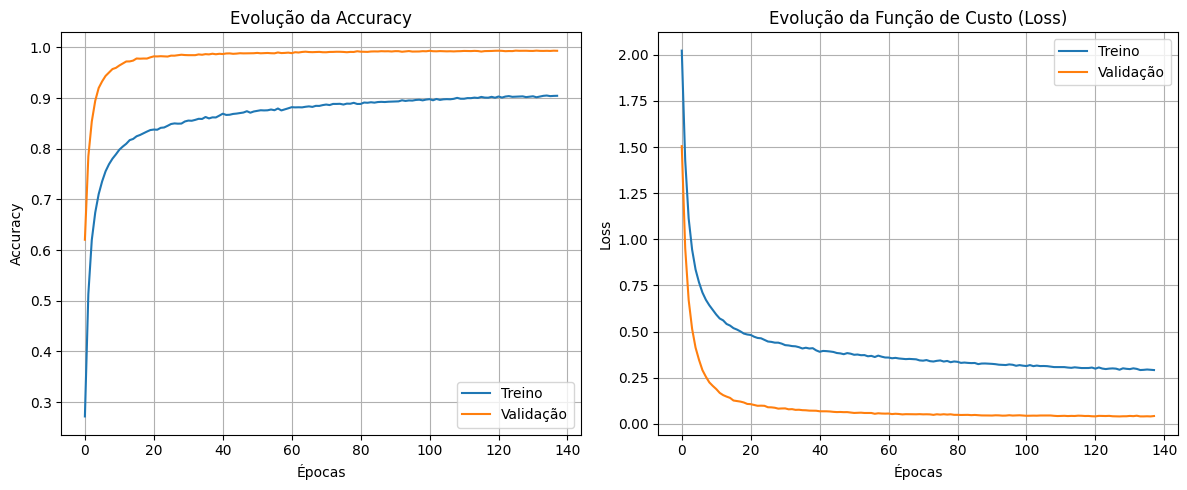

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Softmax
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import categorical_crossentropy
import matplotlib.pyplot as plt

# Normalização
X = X.astype('float32')
if X.max() > 1.0:
    X = X / 255.0

# Flatten (garantir que está em vetores)
if X.ndim > 2:
    X = X.reshape(X.shape[0], -1)

# Garantia de que y está em 1D
y_original = y.copy()
y = np.array(y_original)
if y.ndim > 1:
    y = y[:, 0]
y = y.astype(int)

# One-hot encoding
# Proteção contra múltiplas codificações
if y.ndim > 1 and y.shape[1] == 10 and np.all((y == 0) | (y == 1)):
    y = np.argmax(y, axis=1)

tot_classes = len(np.unique(y))
y = to_categorical(y, num_classes=tot_classes)

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Número de classes: {tot_classes}")

# Divisão treino/validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=np.argmax(y, axis=1))
print(f"Treino: {X_train.shape}, Validação: {X_val.shape}")

# Modelo
model = Sequential()
model.add(Dense(32, input_shape=(X.shape[1],), activation='sigmoid'))
model.add(Dropout(0.3)) # Desativa uma percentagem dos neurónios
model.add(Dense(16, activation='sigmoid'))
model.add(Dropout(0.3))
model.add(Dense(tot_classes))
model.add(Softmax())

# Função de custo
def J(y_true, y_pred):
    return categorical_crossentropy(y_true, y_pred)

# Treino
model.compile(optimizer='adam', loss=J, metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=128, verbose=1, callbacks=[early_stop])

# Avaliação
loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\nLoss: {loss:.4f} - Accuracy: {acc:.4f}")

# Gráficos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Evolução da Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Evolução da Função de Custo (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Na Implementation III, foi utilizada um modelo de duas camadas com 32 e 16 neurónios com activação sigmoid, com um lote de tamanho 128 e um total de 200 épocas, com regularização por Dropout de 30% em ambas as camadas.

\
Graças ao uso do critério de paragem antecipada EarlyStopping, podemos constatar que o treino foi interrompido na **época 129** após a deteção da estagnação da melhoria da função de custo. Nessa época, foi registada uma accuracy de 99.34% e uma loss de 0.0398 na validação.

\
Nos gráficos, também podemos observar uma evolução estável, com a accuracy a tender para 1.0 e a função de custo a descer significativamente.

# **Análise Comparativa**


---



Após a implementação dos três modelos, podemos concluir o seguinte:

* **<u>A Implementation III destacou-se com o melhor desempenho**</u>, beneficiando de uma paragem antecipada eficaz que evitou overfitting e acelerou o treino;

* A Implementation I também apresentou bons resultados, com treino completo até à última época e forte capacidade de generalização;

*  A Implementation II, embora estável, teve um desempenho inferior.
